# SPRINT 11 Marine Fernandez
## NIVEL 1
### Conecta Python con MySQL Workbench y carga los datos de tu base de datos del Sprint 4 para utilizarlas en todos los ejercicios.

In [ ]:
pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import mysql.connector
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


try:
    connection = mysql.connector.connect(host='localhost',database = "sales", user= "root",  password= "1234")
    
    if connection.is_connected():
        db_Info = connection.get_server_info()
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)




Connected to MySQL Server version  8.0.42
You're connected to database:  ('sales',)


C:\Users\marin\AppData\Local\Temp\ipykernel_18188\3510982797.py:12: DeprecationWarning: Call to deprecated function get_server_info. Reason: 
    The property counterpart 'server_info' should be used instead.

  db_Info = connection.get_server_info()


In [2]:
import warnings
warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy connectable.*")

### Para cada ítem, crea una visualización adecuada según las variables especificadas. Interpreta los resultados según tus datos.

In [17]:
#Visualización de una variable categórica : creacion de un gráfico de barras usando Plotly express (countplot)

query = "SELECT* FROM COMPANIES"
df_company= pd.read_sql(query, connection)
figura1= px.histogram(df_company, x="country")

figura1.update_layout(
  title="Cantidad de Empresas por Paises",
  title_font_size= 15,
  xaxis_title="País",
  yaxis_title="Recuento de Empresas", 
  xaxis_title_font_size= 12,
  xaxis={"categoryorder":"total descending"})




**Interpretación**:

Primero hemos cargado la tabla "companies" de la base de datos "sales" desde SQL. 

Hemos creado un gráfico de barras mediante plotly express para representar la cantidad de empresas por países, ordenando de mayor a menor. 

Vemos que Suecia es el país con la mayor cantida de empresas (11 en total) seguido por Holanda. La interactividad proporcionada por Plotly Express nos permite consultar la cantidad exacta de empresas en cada país rapídamente. 


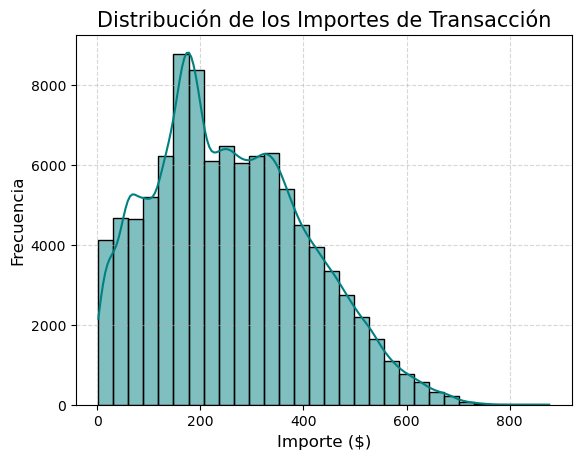

In [ ]:
#Visualización de una variable numérica : creando un histograma usando Seaborn 

query = "SELECT* from transactions"
df_transaction= pd.read_sql(query, connection)

sns.histplot(data=df_transaction, x="amount", bins=30, kde=True, color="teal")
plt.title("Distribución de los Importes de Transacción", fontsize=15)
plt.xlabel("Importe ($)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)




**Interpretación**:

Primero hemos cargado la tabla "transactions" de la base de datos "sales" desde SQL. 

Para visualizar la distrubución del importe de las transacciones mediante la columna "amount" creamos un histograma con Seaborn al cual incluímos una línea de densidad que nos permite identificar rápidamente dónde se concentran las transacciones y mostrando la tendencia general de la distribución."

La distribución del importe de las transacciones es asimétrica. Vemos que la mayor concentración de transacciones ocurre en torno a un ticket de 180 - 200 dolares ya que tenemos un pico en la línea de densidad. 
Las transacciones de ticket elevado (600 - 800 dolares) son pocas pero representa un volumen de ingreso importante. 

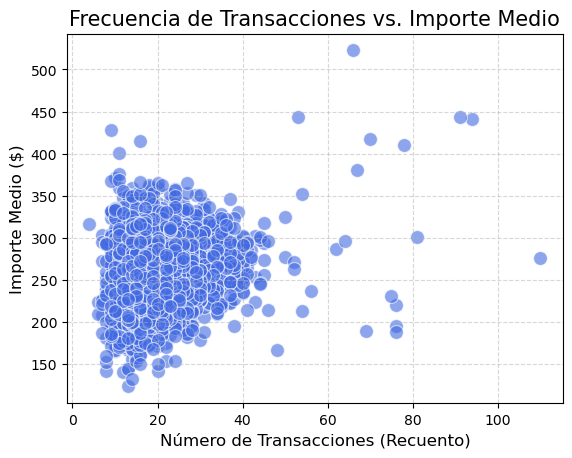

In [19]:
#Visualización de dos variables numéricas: creamos un scatterplot usando seaborn 
#Comparacion del importe medio de las transacciones con la cantidad de transacciones por cliente (recuento)

df_scatter= df_transaction.groupby("user_id").agg(Num_transacciones=("id", "count"), Importe_medio=("amount", "mean")).reset_index()


sns.scatterplot(data=df_scatter, x="Num_transacciones", y="Importe_medio", alpha=0.6, s=100, color="royalblue")

plt.title("Frecuencia de Transacciones vs. Importe Medio", fontsize=15)
plt.xlabel("Número de Transacciones (Recuento)", fontsize=12)
plt.ylabel("Importe Medio ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

**Interpretación**: 

Para analizar el perfil de los clientes decidimos comparar la cantidad de transacciones con el importe medio de cada una por clientes. Para ello, usamos el data frame df_transaction para crear un nuevo dataframe "df_scatter" agrupando por clientes y calculando la cantidad de compras (transacciones) y la media de los tickets.

Hemos usado ese  nuevo dataframe para crear un gráfico de dispersión con seaborn. 

Vemos diferentes tipos de usuarios: 
- Perfil Estándar (El grupo central de puntos): Clientes que compran de vez en cuando (10-30 veces) con un gasto medio moderado.

- Perfil VIP (Los puntos altos): Usuarios que no compran siempre, pero cuando lo hacen, gastan mucho más que la media.

- Perfil Fiel  (Los puntos a la derecha): clientes recurrentes que realizan muchísimas transacciones, aunque su gasto por cada una sea normal.

In [12]:
#Visualización de una variable categórica y una numérica: creamos un gráfico de barras usando plotly express
#Importe medio de transacciones por empresas (top 5)

df_transaction_company= pd.merge(df_transaction, df_company, left_on= "business_id", right_on="company_id")

top5_company= df_transaction_company.groupby("company_name")[["amount"]].mean().round(2).sort_values(by="amount", ascending=False).head(5)
top5_company= top5_company.reset_index()
top5_company.columns= ["Nombre_empresa","Importe_medio ($)"]
top5_company



,Nombre_empresa,Importe_medio ($)
0,Ac Fermentum Incorporated,284.87
1,Pretium Neque Corp.,276.16
2,Urna Convallis Associates,274.24
3,At Associates,272.21
4,Metus Vitae Associates,270.08


In [14]:
px.bar(data_frame=top5_company, x= "Nombre_empresa", y= "Importe_medio ($)", title= "Top 5 del importe medio de transaccion por empresas")


**Interpretación**: 

Decidimos analizar el ticket medio de ventas por empresas, para ello primero juntamos los dataframes df_companies y df_transactions usando un merge. A partir de ese dataframe df_transaction_company constituimos un dataframe agrupado por empresas con el promedio de ticket calculado y lo hemos limitado a las 5 empresas con mayor ticket promedio. 

Hemos usado ese dataframe para realizar un gráfico de barras usando plotly express por su interactividad. 

Vemos que la empresa con el ticket promedio más alto es Ac Fermentum Incorporated (284.87 dolares). Sin embargo esas 5 empresas tienen un ticket promedio muy similar. 
 

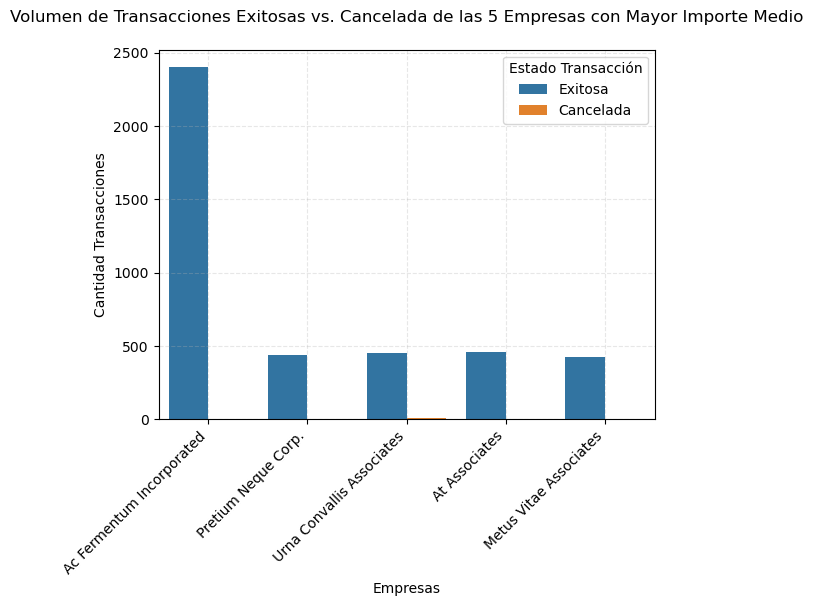

In [13]:
#Visualización de dos variables categóricas: creamos un gráfico de barras agrupadas con Seaborn 

df_top5 =pd.merge(top5_company, df_transaction_company, left_on="Nombre_empresa", right_on= "company_name")

sns.countplot(x="Nombre_empresa", hue="declined", data= df_top5)
plt.title("Volumen de Transacciones Exitosas vs. Cancelada de las 5 Empresas con Mayor Importe Medio", pad=20)
plt.xlabel("Empresas")
plt.ylabel("Cantidad Transacciones")
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Estado Transacción", labels=["Exitosa", "Cancelada"])

**Interpretación**: 

Procedimos a verificar la robustez de la actividad del top 5 de empresas, representando el estado de las transacciones realizadas (aprobadas o canceladas). 

Para ello, juntamos los dataframes del top 5 de empresas con el dataframe de las transacciones agrupado por compañías, aplicando un merge. 

Posteriormente visualizamos el recuento del estado de las transacciones por cada empresas mediante un gráfico de barras agrupadas (sns.countplot) segmentando por la variable categorica "declined". 
Esto nos permite comparar cuántas operaciones llegaron a buen término frente a las canceladas para cada empresa.

Vemos que la empresa Ac Fermentum Incorporated no solo lidera en ticket promedio (cf Gráfica "Top 5 del importe medio de transaccion por empresas"), sino que muestra un volumen de transacciones significativamente superior. Las demás empresas del Top 5 muestran un volumen de transacciones similares y de forma global vemos que la cantidad de ventas canceladas es casi inexistente. 


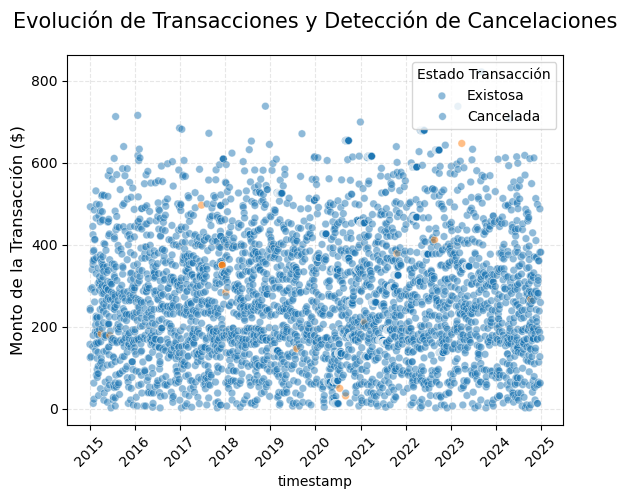

In [ ]:
#Visualización de 3 categorías combinadas: creamos un diagrama de dispersión usando seaborn


df_top5= df_top5.sort_values(by="timestamp") 

sns.scatterplot(data=df_top5, x="timestamp", y="amount", hue="declined", alpha=0.5, s=30)
   

plt.title("Evolución de Transacciones y Detección de Cancelaciones", fontsize=15, pad=20)
plt.ylabel("Monto de la Transacción ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title="Estado Transacción",labels=["Existosa", "Cancelada"], loc="upper right")

**Interpretación**:

Hemos decidido analizar de distribución de los montos de las operaciones a lo largo del tiempo usando el mismo dataframe que para el gráfico precedente, ordenándolo por orden cronológico (usando sort.values). 

Cremos un gráfico de dispersión con Seaborn usando las columnas "timestamp" y "amount" como ejes X y Y y categorizamos con la columna "declined" para diferenciar las transacciones finalizadas de las canceladas usando colores. 

Vemos que no existe un patrón de tiempo ni un rango de monto que cause las cancelaciones. Esto sugiere que las transacciones fallidas son eventos aleatorios (como errores técnicos puntuales o límites de tarjeta) y no un problema sistémico de las empresas o de la plataforma

In [22]:
#Crear un pairplot

df_transaction_company["ano"]=df_transaction_company["timestamp"].dt.year

df_resumen=df_transaction_company.groupby("ano").agg(Recuento_Ventas=("id","count"), Total_Ventas=("amount","sum"), Importe_medio=("amount", "mean"),Transacciones_declinadas=("declined", "sum")).round(2)
df_resumen.reset_index()



,ano,Recuento_Ventas,Total_Ventas,Importe_medio,Transacciones_declinadas
0,2015,9870,2545190.07,257.87,27
1,2016,9855,2556344.72,259.40,16
2,2017,9915,2571455.22,259.35,27
3,2018,9912,2546896.83,256.95,23
4,2019,10015,2610818.43,260.69,28
5,2020,10093,2607486.59,258.35,18
6,2021,10298,2649462.92,257.28,26
7,2022,10106,2640035.64,261.23,14
8,2023,9985,2580524.58,258.44,20
9,2024,9951,2593316.17,260.61,38


Text(0.5, 1.03, 'Comparativa de Métricas de Ventas (2015-2024)')

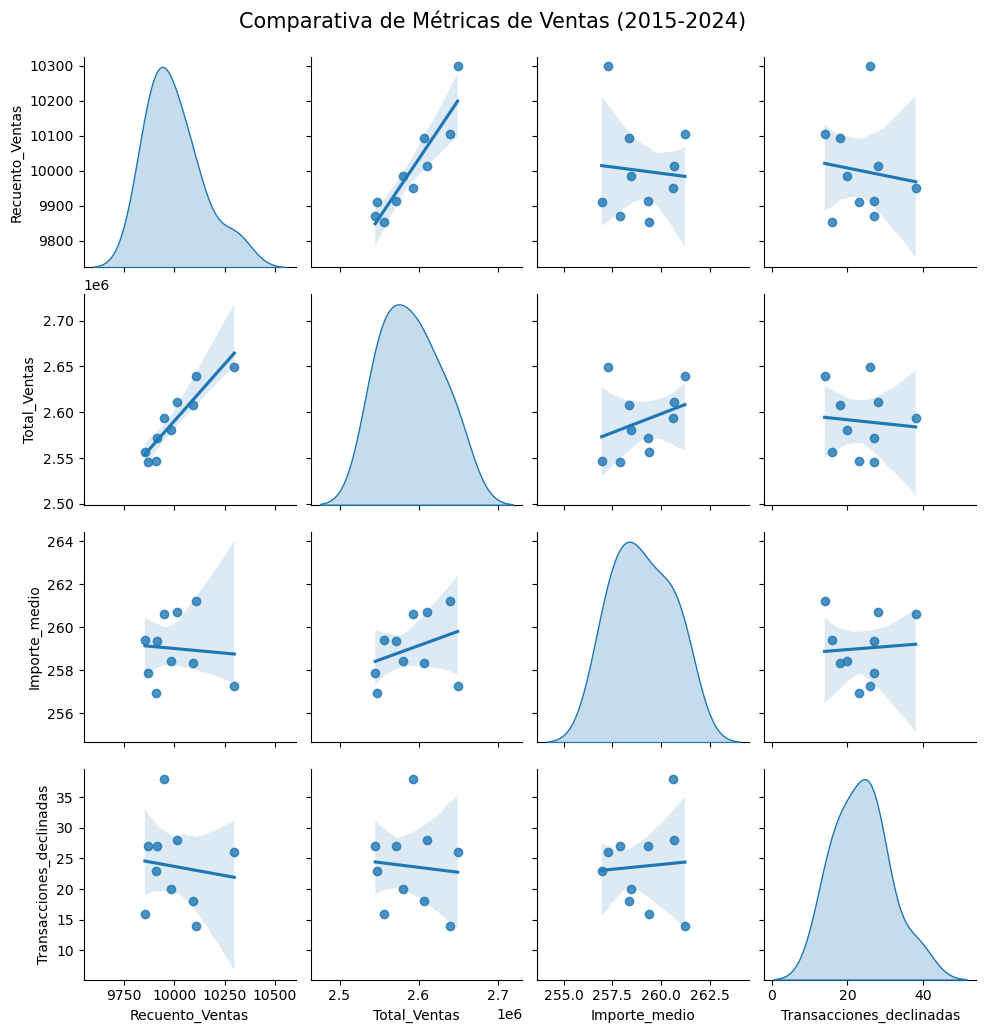

In [23]:
sns.pairplot(df_resumen, kind="reg", diag_kind= "kde")

plt.suptitle("Comparativa de Métricas de Ventas (2015-2024)", fontsize= 15, y=1.03)

**Interpretación**: 

Para finalizar el estudio, hemos generado un pairplot que cruza las métricas anuales de ventas.
Primero, hemos extraído los años de la columna "timestamp" del dataframe "df_transaction_company" para posteriormente generar un nuevo dataframe de resumen de las métricas de las transacciones agrupado por años. 

En la diagonal del pairplot creado, vemos curvas de densidad que muestran la distribución de cada métrica.
En los cuadros laterales, vemos gráficos de dispersión con una línea de regresión que nos indica la tendencia (si existe una correlación). 

Notamos una correlación fuerte entre el monto total de las ventas y la cantidad de ventas realizados (segundo grágico de la primera línea), es decir que el aumento del beneficio depende directamente de la cantidad de ventas. El ticket medio se mantiene estable a través del tiempo (entre 256 y 264 dolares) y no varia en función de las demás métricas. 

Podemos concluir que el crecimiento de la plataforma está vinculado al volumen de transacciones más que al aumento de ticket medio y podría ser predictible. 

In [ ]:
#Cerramos la sesion 

    if connection.is_connected():
        cursor.close()
        #onnection.close()
        "print("MySQL connection is closed")